<strong>The dataset is about the compressive strength of different samples of concrete based on the volumes of the different ingredients that were used to make them. Ingredients include:</strong>

* Cement
* Blast furnace slag
* Fly ash
* Water
* Superplasticizer
* Coarse aggregate
* Fine aggregate

#### Find strength of concrete

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
df = pd.read_csv('https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0101EN/labs/data/concrete_data.csv')
df.head()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


#### So the first concrete sample has 540 cubic meter of cement, 0 cubic meter of blast furnace slag, 0 cubic meter of fly ash, 162 cubic meter of water, 2.5 cubic meter of superplaticizer, 1040 cubic meter of coarse aggregate, 676 cubic meter of fine aggregate. Such a concrete mix which is 28 days old, has a compressive strength of 79.99 MPa.

In [3]:
df.shape

(1030, 9)

In [4]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [5]:
#SEPRATE DATA INTO FEATURES AND LABELS

concrete_Column = df.columns

input = df[concrete_Column[concrete_Column != 'Strength']]
output = df['Strength']


<img src="https://spreadsheetweb.com/wp-content/uploads/2020/07/How-to-normalize-data-in-Excel-00.png" width="500">

In [6]:
input_norm =(input - input.mean())//input.std()
input_norm.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,2.0,-1.0,-1.0,-1.0,-1.0,0.0,-2.0,-1.0
1,2.0,-1.0,-1.0,-1.0,-1.0,1.0,-2.0,-1.0
2,0.0,0.0,-1.0,2.0,-2.0,-1.0,-3.0,3.0
3,0.0,0.0,-1.0,2.0,-2.0,-1.0,-3.0,5.0
4,-1.0,0.0,-1.0,0.0,-2.0,0.0,0.0,4.0


why we normalize the data

We normalize data in neural networks for several critical reasons:

* Equal Feature Importance

Your concrete features have very different scales (e.g., cement might be 100-500 kg/m³, while superplasticizer is 0-30 kg/m³)
Without normalization, features with larger values dominate the learning process

* Faster Convergence

Neural networks train much faster when all inputs are on a similar scale (typically mean=0, std=1)
Gradient descent converges more quickly and smoothly

* Prevents Gradient Issues

Large input values can cause exploding gradients
Small input values can cause vanishing gradients
Normalized data keeps gradients in a healthy range
* Better Weight Initialization

Neural network weights are typically initialized for normalized inputs
Unnormalized data can make initial weights ineffective

* Numerical Stability

Prevents overflow/underflow errors during computation
Makes the optimization landscape smoother and easier to navigate

In [7]:
n_cols = input_norm.shape[1]
n_cols

8

In [8]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input

### Build a Neural Network


In [9]:
def regression_model():
    model = Sequential()
    model.add(Input(shape=(n_cols,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


* Adam (Adaptive Moment Estimation) is an optimization algorithm used to train neural networks by updating the weights to minimize the loss function.

In [10]:
model = regression_model()
model.fit(input_norm, output, validation_split=0.2, epochs=100, verbose=1)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1562.9424 - val_loss: 1094.5725
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1383.4406 - val_loss: 889.8528
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1058.0596 - val_loss: 550.3776
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 628.6385 - val_loss: 232.7877
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 344.0172 - val_loss: 156.9458
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 256.2466 - val_loss: 177.0174
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 226.9121 - val_loss: 186.2587
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 214.5738 - val_loss: 183.7873
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 206.5009 - val_loss: 186.7754
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 200.8617 - val_loss: 186.0103
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 195.3972 - val_loss: 189.2401
Epoch 12/100
26

In [11]:
# Make predictions
predictions = model.predict(input_norm)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(output, predictions)
mae = mean_absolute_error(output, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(output, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Squared Error (MSE): 102.48
Root Mean Squared Error (RMSE): 10.12
Mean Absolute Error (MAE): 7.90
R² Score: 0.6324


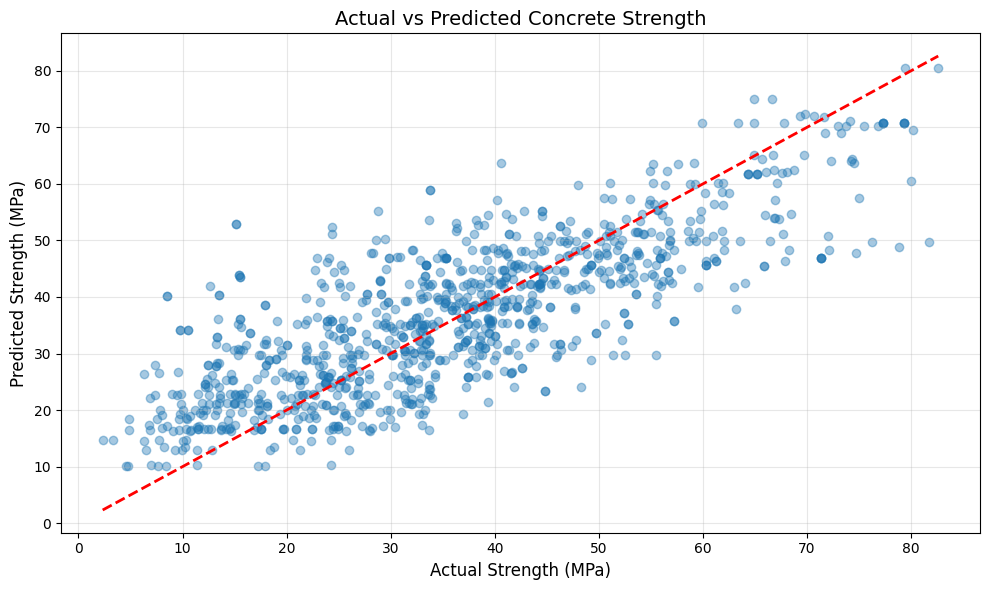

In [12]:
# Visualize Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(output, predictions, alpha=0.4)
plt.plot([output.min(), output.max()], [output.min(), output.max()], 'r--', lw=2)
plt.xlabel('Actual Strength (MPa)', fontsize=12)
plt.ylabel('Predicted Strength (MPa)', fontsize=12)
plt.title('Actual vs Predicted Concrete Strength', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### View Learned Weights and Biases

In [13]:
# Get all layers and their weights
print("Model Architecture:")
print("=" * 60)
for i, layer in enumerate(model.layers):
    print(f"\nLayer {i+1}: {layer.name}")
    weights = layer.get_weights()
    if weights:
        w, b = weights[0], weights[1]
        print(f"  Weights shape: {w.shape}")
        print(f"  Biases shape: {b.shape}")
        print(f"  Total parameters: {w.size + b.size}")

Model Architecture:

Layer 1: dense
  Weights shape: (8, 50)
  Biases shape: (50,)
  Total parameters: 450

Layer 2: dense_1
  Weights shape: (50, 50)
  Biases shape: (50,)
  Total parameters: 2550

Layer 3: dense_2
  Weights shape: (50, 1)
  Biases shape: (1,)
  Total parameters: 51


In [14]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,155 (35.77 KB)

 Trainable params: 3,051 (11.92 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,104 (23.85 KB)